# Market Differentiated Bars

## Overview

This notebook demonstrates the public functions in `market_differentiated_bars`.
- Problem: integer differencing can remove more memory than is needed to make a price series stationary.
- Approach: diagnose a minimum stationary differencing order for each bar type and apply that order to its log-close series.

## Observed Data

This cell loads observed tick, volume, and dollar bars used by the diagnostics and transformations.
- `feature_dir` identifies the source and output directory at `../../data/research_data/market/features`.
- `symbol_slug` identifies the instrument in source and output file names.
- `period_slug` identifies the inclusive observation period in source and output file names.
- `tick_bar_path` identifies the observed tick-bar Parquet file.
- `volume_bar_path` identifies the observed volume-bar Parquet file.
- `dollar_bar_path` identifies the observed dollar-bar Parquet file.
- `tick_bars` contains bars formed by a fixed number of source observations.
- `volume_bars` contains bars formed by a fixed amount of traded share volume.
- `dollar_bars` contains bars formed by a fixed amount of traded dollar value.
- `end` identifies each bar's final source timestamp in UTC.
- `close` contains each bar's final observed price in dollars.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.data_preprocessing.market_differentiated_bars import (
    fractional_difference_fixed_width,
    plot_min_ffd,
)

feature_dir = Path(
    "../../data/research_data/market/features"
)
symbol_slug = "aapl"
period_slug = "2025-01-01_2025-12-31"

tick_bar_path = feature_dir / (
    f"{symbol_slug}_tick_bar_{period_slug}.parquet"
)
volume_bar_path = feature_dir / (
    f"{symbol_slug}_volume_bar_{period_slug}.parquet"
)
dollar_bar_path = feature_dir / (
    f"{symbol_slug}_dollar_bar_{period_slug}.parquet"
)

tick_bars = pd.read_parquet(tick_bar_path)
volume_bars = pd.read_parquet(volume_bar_path)
dollar_bars = pd.read_parquet(dollar_bar_path)

display(tick_bars[["end", "close"]].head())
display(volume_bars[["end", "close"]].head())
display(dollar_bars[["end", "close"]].head())

,end,close
0,2025-01-02 14:30:00.427502+00:00,248.930
1,2025-01-02 14:30:01.547491+00:00,248.820
2,2025-01-02 14:30:01.975434+00:00,248.620
3,2025-01-02 14:30:02.460014+00:00,248.685
4,2025-01-02 14:30:02.769496+00:00,248.610


,end,close
0,2025-01-02 14:30:01.004279+00:00,248.91
1,2025-01-02 14:30:02.119118+00:00,248.65
2,2025-01-02 14:30:02.891073+00:00,248.59
3,2025-01-02 14:30:04.394582+00:00,248.61
4,2025-01-02 14:30:05.069868+00:00,248.56


,end,close
0,2025-01-02 14:30:01.004279+00:00,248.91
1,2025-01-02 14:30:02.119118+00:00,248.65
2,2025-01-02 14:30:02.891073+00:00,248.59
3,2025-01-02 14:30:04.394582+00:00,248.61
4,2025-01-02 14:30:05.084156+00:00,248.58


## Tick Bar Minimum Differencing Diagnostic

This cell identifies the minimum fixed-width fractional-differencing order whose transformed tick-bar log-close series rejects a unit root at the 5% level.
- `tick_bar_close_frame` contains the final tick-bar prices in dollars.
- `tick_bar_log_close_frame` contains the natural logarithm of each strictly positive `close` value.
- `weight_cutoff` sets the absolute fixed-width weight cutoff used for every bar type and evaluated order.
- `differencing_orders` contains the candidate orders from `0.0` through `1.0` in increments of `0.1`.
- `tick_bar_minimum_ffd_diagnostic` reports stationarity and memory retention for each candidate order.
- `tick_bar_stationary_orders` contains the orders whose `adf_statistic` is below `critical_value_5pct`.
- `tick_bar_selected_d` is the smallest order that rejects the unit-root null hypothesis at the 5% level.
- `adf_statistic` contains the augmented Dickey-Fuller statistic for each order.
- `p_value` contains the unit-root test p-value.
- `used_lags` contains the number of lagged differences included by the test.
- `n_observations` contains the number of observations used by the test.
- `critical_value_5pct` contains the 5% critical value for rejecting a unit root.
- `correlation` contains the correlation between the transformed series and the original log-close series.
- The horizontal axis represents the fractional-differencing order.
- The primary vertical axis represents `correlation`, and the secondary vertical axis represents `adf_statistic`.
- The dotted horizontal line marks the mean `critical_value_5pct`, so the first statistic below it identifies `tick_bar_selected_d`.

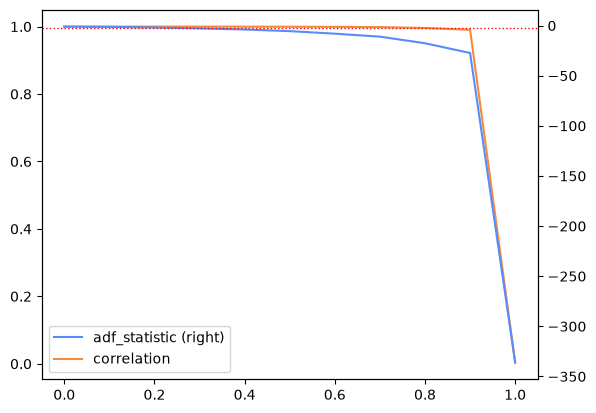

Selected differencing order: 0.4


,adf_statistic,p_value,used_lags,n_observations,critical_value_5pct,correlation
0.0,-0.989860,7.569445e-01,1.0,223225.0,-2.861553,1.000000
0.1,-1.301513,6.284799e-01,1.0,223218.0,-2.861553,0.999998
0.2,-1.902011,3.311156e-01,1.0,223215.0,-2.861553,0.999981
0.3,-2.776263,6.174526e-02,1.0,223214.0,-2.861553,0.999931
0.4,-3.898066,2.049123e-03,1.0,223215.0,-2.861553,0.999833
0.5,-5.542871,1.686178e-06,1.0,223216.0,-2.861553,0.999626
0.6,-8.069257,1.565589e-12,1.0,223217.0,-2.861553,0.999166
0.7,-11.020137,6.016565e-20,1.0,223219.0,-2.861553,0.998450
0.8,-17.602403,3.915530e-30,1.0,223220.0,-2.861553,0.995983
0.9,-27.332584,0.000000e+00,1.0,223222.0,-2.861553,0.990400


In [5]:
tick_bar_close_frame = tick_bars[["close"]].astype(float)
tick_bar_log_close_frame = np.log(
    tick_bar_close_frame
).rename(columns={"close": "log_close"})

weight_cutoff = 0.01
differencing_orders = np.linspace(0.0, 1.0, 11)

tick_bar_minimum_ffd_diagnostic = plot_min_ffd(
    tick_bar_log_close_frame,
    weight_cutoff=weight_cutoff,
    differencing_orders=differencing_orders,
)
tick_bar_stationary_orders = (
    tick_bar_minimum_ffd_diagnostic.index[
        tick_bar_minimum_ffd_diagnostic["adf_statistic"]
        < tick_bar_minimum_ffd_diagnostic["critical_value_5pct"]
    ]
)
tick_bar_selected_d = tick_bar_stationary_orders.min()

print(f"Selected differencing order: {tick_bar_selected_d:.1f}")
tick_bar_minimum_ffd_diagnostic

## Tick Bar Fractional Difference

This cell applies the selected order to the tick-bar log-close series, saves the retained values, and visualizes only the transformed series.
- `tick_bar_fractionally_differenced_log_close` contains the transformed log-close values at retained source row positions.
- `tick_bar_fractional_bars` aligns each transformed value with its original UTC endpoint.
- `end` identifies the original tick-bar endpoint in UTC and can contain repeated timestamps.
- `fractionally_differenced_log_close` contains the fixed-width fractional difference in log-price units.
- `tick_bar_fractional_output_path` identifies the saved Parquet result in `feature_dir`.
- The horizontal axis represents the original tick-bar `end` timestamp in UTC.
- The vertical axis represents `fractionally_differenced_log_close`.

../../data/research_data/market/features/aapl_tick_bar_fractional_2025-01-01_2025-12-31.parquet


,end,fractionally_differenced_log_close
10,2025-01-02 14:30:13.114217+00:00,1.456760
11,2025-01-02 14:30:24.158285+00:00,1.456495
12,2025-01-02 14:30:40.442445+00:00,1.456709
13,2025-01-02 14:30:48.972536+00:00,1.456097
14,2025-01-02 14:30:55.886206+00:00,1.455378


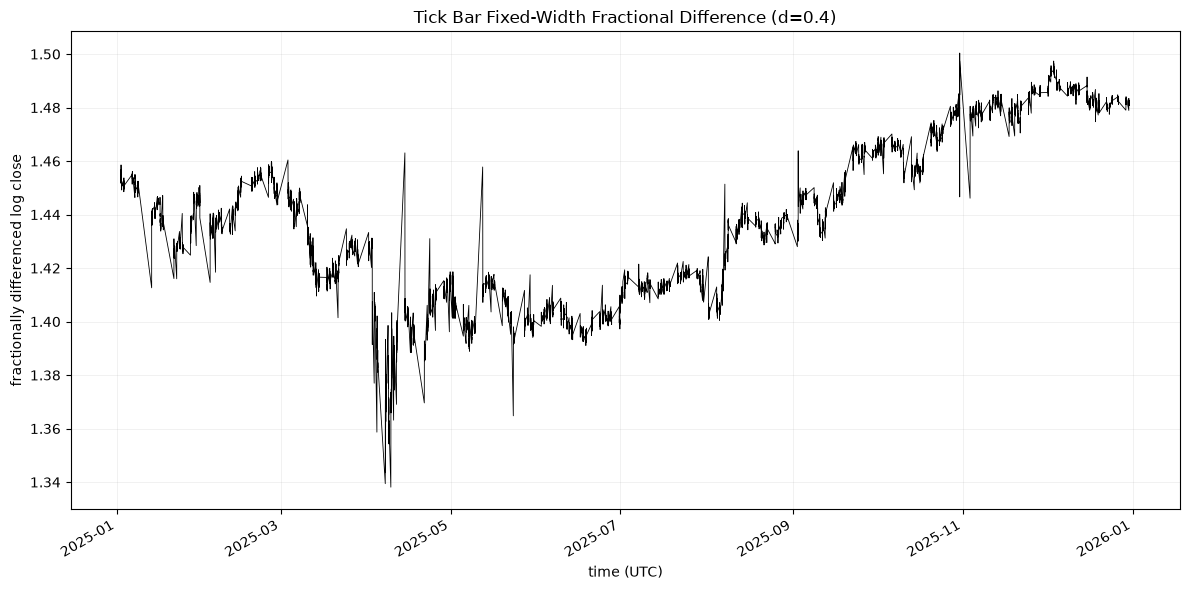

In [6]:
tick_bar_fractionally_differenced_log_close = (
    fractional_difference_fixed_width(
        tick_bar_log_close_frame,
        differencing_order=tick_bar_selected_d,
        weight_cutoff=weight_cutoff,
    )
)
tick_bar_fractional_bars = tick_bars.loc[
    tick_bar_fractionally_differenced_log_close.index,
    ["end"],
].copy()
tick_bar_fractional_bars[
    "fractionally_differenced_log_close"
] = tick_bar_fractionally_differenced_log_close["log_close"]

tick_bar_fractional_output_path = feature_dir / (
    f"{symbol_slug}_tick_bar_fractional_{period_slug}.parquet"
)
tick_bar_fractional_bars.to_parquet(
    tick_bar_fractional_output_path,
    index=False,
)

print(tick_bar_fractional_output_path)
display(tick_bar_fractional_bars.head())

tick_bar_figure, tick_bar_axis = plt.subplots(figsize=(12, 6))
tick_bar_fractional_bars.set_index("end")[
    "fractionally_differenced_log_close"
].plot(ax=tick_bar_axis, color="black", linewidth=0.6)
tick_bar_axis.set_xlabel("time (UTC)")
tick_bar_axis.set_ylabel("fractionally differenced log close")
tick_bar_axis.set_title(
    "Tick Bar Fixed-Width Fractional Difference "
    f"(d={tick_bar_selected_d:.1f})"
)
tick_bar_axis.grid(alpha=0.25)
tick_bar_figure.tight_layout()
plt.show()

## Volume Bar Minimum Differencing Diagnostic

This cell identifies the minimum fixed-width fractional-differencing order whose transformed volume-bar log-close series rejects a unit root at the 5% level.
- `volume_bar_close_frame` contains the final volume-bar prices in dollars.
- `volume_bar_log_close_frame` contains the natural logarithm of each strictly positive `close` value.
- `volume_bar_minimum_ffd_diagnostic` reports stationarity and memory retention for each candidate order in `differencing_orders` using `weight_cutoff`.
- `volume_bar_stationary_orders` contains the orders whose `adf_statistic` is below `critical_value_5pct`.
- `volume_bar_selected_d` is the smallest order that rejects the unit-root null hypothesis at the 5% level.
- `adf_statistic` contains the augmented Dickey-Fuller statistic for each order.
- `p_value` contains the unit-root test p-value.
- `used_lags` contains the number of lagged differences included by the test.
- `n_observations` contains the number of observations used by the test.
- `critical_value_5pct` contains the 5% critical value for rejecting a unit root.
- `correlation` contains the correlation between the transformed series and the original log-close series.
- The horizontal axis represents the fractional-differencing order.
- The primary vertical axis represents `correlation`, and the secondary vertical axis represents `adf_statistic`.
- The dotted horizontal line marks the mean `critical_value_5pct`, so the first statistic below it identifies `volume_bar_selected_d`.

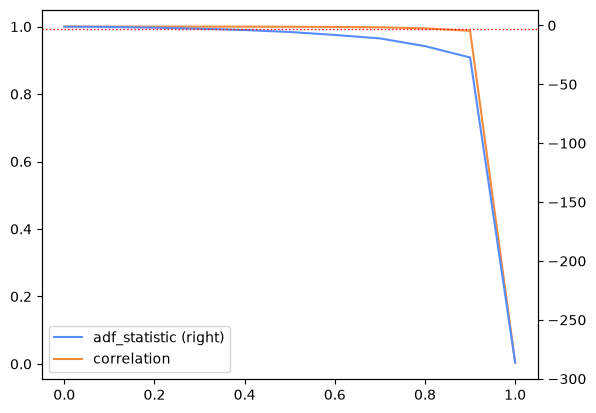

Selected differencing order: 0.4


,adf_statistic,p_value,used_lags,n_observations,critical_value_5pct,correlation
0.0,-1.034744,7.403823e-01,1.0,169990.0,-2.861557,1.000000
0.1,-1.346249,6.077571e-01,1.0,169983.0,-2.861557,0.999997
0.2,-1.951969,3.080216e-01,1.0,169980.0,-2.861557,0.999974
0.3,-2.839300,5.287568e-02,1.0,169979.0,-2.861557,0.999908
0.4,-3.958300,1.645315e-03,1.0,169980.0,-2.861557,0.999778
0.5,-5.606903,1.228339e-06,1.0,169981.0,-2.861557,0.999503
0.6,-8.129044,1.102921e-12,1.0,169982.0,-2.861557,0.998896
0.7,-11.065835,4.684331e-20,1.0,169984.0,-2.861557,0.997959
0.8,-17.616502,3.857019e-30,1.0,169985.0,-2.861557,0.994748
0.9,-27.247596,0.000000e+00,1.0,169987.0,-2.861557,0.987563


In [7]:
volume_bar_close_frame = volume_bars[["close"]].astype(float)
volume_bar_log_close_frame = np.log(
    volume_bar_close_frame
).rename(columns={"close": "log_close"})

volume_bar_minimum_ffd_diagnostic = plot_min_ffd(
    volume_bar_log_close_frame,
    weight_cutoff=weight_cutoff,
    differencing_orders=differencing_orders,
)
volume_bar_stationary_orders = (
    volume_bar_minimum_ffd_diagnostic.index[
        volume_bar_minimum_ffd_diagnostic["adf_statistic"]
        < volume_bar_minimum_ffd_diagnostic["critical_value_5pct"]
    ]
)
volume_bar_selected_d = volume_bar_stationary_orders.min()

print(f"Selected differencing order: {volume_bar_selected_d:.1f}")
volume_bar_minimum_ffd_diagnostic

## Volume Bar Fractional Difference

This cell applies the selected order to the volume-bar log-close series, saves the retained values, and visualizes only the transformed series.
- `volume_bar_fractionally_differenced_log_close` contains the transformed log-close values at retained source row positions.
- `volume_bar_fractional_bars` aligns each transformed value with its original UTC endpoint.
- `end` identifies the original volume-bar endpoint in UTC and can contain repeated timestamps.
- `fractionally_differenced_log_close` contains the fixed-width fractional difference in log-price units.
- `volume_bar_fractional_output_path` identifies the saved Parquet result in `feature_dir`.
- The horizontal axis represents the original volume-bar `end` timestamp in UTC.
- The vertical axis represents `fractionally_differenced_log_close`.

../../data/research_data/market/features/aapl_volume_bar_fractional_2025-01-01_2025-12-31.parquet


,end,fractionally_differenced_log_close
10,2025-01-02 14:30:41.213855+00:00,1.456866
11,2025-01-02 14:30:51.377662+00:00,1.455723
12,2025-01-02 14:31:11.718819+00:00,1.459326
13,2025-01-02 14:31:19.128211+00:00,1.456684
14,2025-01-02 14:31:36.970130+00:00,1.455565


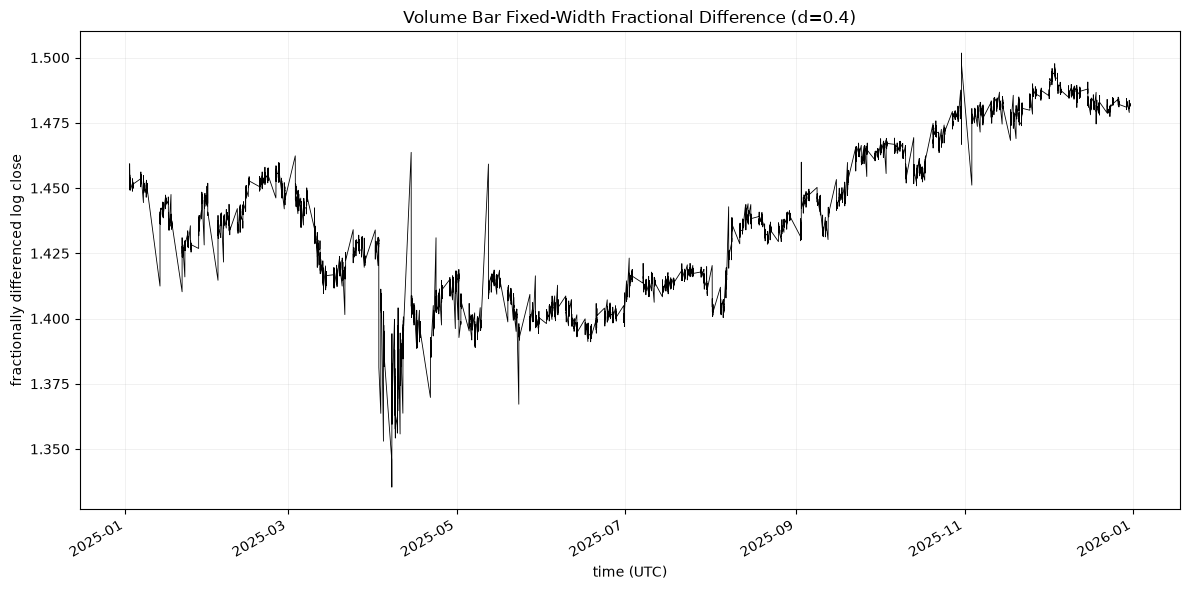

In [8]:
volume_bar_fractionally_differenced_log_close = (
    fractional_difference_fixed_width(
        volume_bar_log_close_frame,
        differencing_order=volume_bar_selected_d,
        weight_cutoff=weight_cutoff,
    )
)
volume_bar_fractional_bars = volume_bars.loc[
    volume_bar_fractionally_differenced_log_close.index,
    ["end"],
].copy()
volume_bar_fractional_bars[
    "fractionally_differenced_log_close"
] = volume_bar_fractionally_differenced_log_close["log_close"]

volume_bar_fractional_output_path = feature_dir / (
    f"{symbol_slug}_volume_bar_fractional_{period_slug}.parquet"
)
volume_bar_fractional_bars.to_parquet(
    volume_bar_fractional_output_path,
    index=False,
)

print(volume_bar_fractional_output_path)
display(volume_bar_fractional_bars.head())

volume_bar_figure, volume_bar_axis = plt.subplots(figsize=(12, 6))
volume_bar_fractional_bars.set_index("end")[
    "fractionally_differenced_log_close"
].plot(ax=volume_bar_axis, color="black", linewidth=0.6)
volume_bar_axis.set_xlabel("time (UTC)")
volume_bar_axis.set_ylabel("fractionally differenced log close")
volume_bar_axis.set_title(
    "Volume Bar Fixed-Width Fractional Difference "
    f"(d={volume_bar_selected_d:.1f})"
)
volume_bar_axis.grid(alpha=0.25)
volume_bar_figure.tight_layout()
plt.show()

## Dollar Bar Minimum Differencing Diagnostic

This cell identifies the minimum fixed-width fractional-differencing order whose transformed dollar-bar log-close series rejects a unit root at the 5% level.
- `dollar_bar_close_frame` contains the final dollar-bar prices in dollars.
- `dollar_bar_log_close_frame` contains the natural logarithm of each strictly positive `close` value.
- `dollar_bar_minimum_ffd_diagnostic` reports stationarity and memory retention for each candidate order in `differencing_orders` using `weight_cutoff`.
- `dollar_bar_stationary_orders` contains the orders whose `adf_statistic` is below `critical_value_5pct`.
- `dollar_bar_selected_d` is the smallest order that rejects the unit-root null hypothesis at the 5% level.
- `adf_statistic` contains the augmented Dickey-Fuller statistic for each order.
- `p_value` contains the unit-root test p-value.
- `used_lags` contains the number of lagged differences included by the test.
- `n_observations` contains the number of observations used by the test.
- `critical_value_5pct` contains the 5% critical value for rejecting a unit root.
- `correlation` contains the correlation between the transformed series and the original log-close series.
- The horizontal axis represents the fractional-differencing order.
- The primary vertical axis represents `correlation`, and the secondary vertical axis represents `adf_statistic`.
- The dotted horizontal line marks the mean `critical_value_5pct`, so the first statistic below it identifies `dollar_bar_selected_d`.

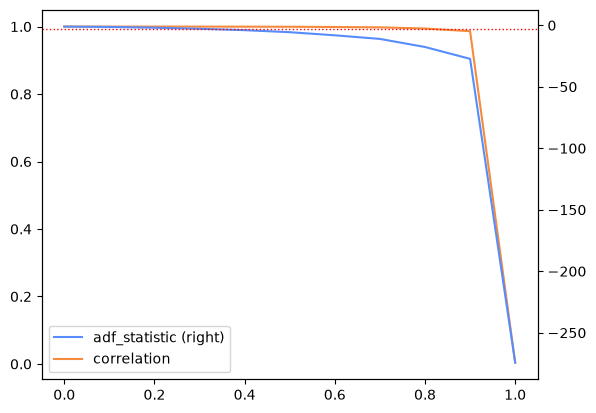

Selected differencing order: 0.4


,adf_statistic,p_value,used_lags,n_observations,critical_value_5pct,correlation
0.0,-1.066527,7.282344e-01,1.0,156777.0,-2.861558,1.000000
0.1,-1.374186,5.945874e-01,1.0,156770.0,-2.861558,0.999997
0.2,-1.975255,2.975270e-01,1.0,156767.0,-2.861558,0.999972
0.3,-2.858396,5.040428e-02,1.0,156766.0,-2.861558,0.999899
0.4,-3.977197,1.534738e-03,1.0,156767.0,-2.861558,0.999757
0.5,-5.625967,1.117234e-06,1.0,156768.0,-2.861558,0.999457
0.6,-8.150996,9.697085e-13,1.0,156769.0,-2.861558,0.998792
0.7,-11.092545,4.048186e-20,1.0,156771.0,-2.861558,0.997763
0.8,-17.654490,3.706856e-30,1.0,156772.0,-2.861558,0.994239
0.9,-27.297711,0.000000e+00,1.0,156774.0,-2.861558,0.986353


In [9]:
dollar_bar_close_frame = dollar_bars[["close"]].astype(float)
dollar_bar_log_close_frame = np.log(
    dollar_bar_close_frame
).rename(columns={"close": "log_close"})

dollar_bar_minimum_ffd_diagnostic = plot_min_ffd(
    dollar_bar_log_close_frame,
    weight_cutoff=weight_cutoff,
    differencing_orders=differencing_orders,
)
dollar_bar_stationary_orders = (
    dollar_bar_minimum_ffd_diagnostic.index[
        dollar_bar_minimum_ffd_diagnostic["adf_statistic"]
        < dollar_bar_minimum_ffd_diagnostic["critical_value_5pct"]
    ]
)
dollar_bar_selected_d = dollar_bar_stationary_orders.min()

print(f"Selected differencing order: {dollar_bar_selected_d:.1f}")
dollar_bar_minimum_ffd_diagnostic

## Dollar Bar Fractional Difference

This cell applies the selected order to the dollar-bar log-close series, saves the retained values, and visualizes only the transformed series.
- `dollar_bar_fractionally_differenced_log_close` contains the transformed log-close values at retained source row positions.
- `dollar_bar_fractional_bars` aligns each transformed value with its original UTC endpoint.
- `end` identifies the original dollar-bar endpoint in UTC and can contain repeated timestamps.
- `fractionally_differenced_log_close` contains the fixed-width fractional difference in log-price units.
- `dollar_bar_fractional_output_path` identifies the saved Parquet result in `feature_dir`.
- The horizontal axis represents the original dollar-bar `end` timestamp in UTC.
- The vertical axis represents `fractionally_differenced_log_close`.

../../data/research_data/market/features/aapl_dollar_bar_fractional_2025-01-01_2025-12-31.parquet


,end,fractionally_differenced_log_close
10,2025-01-02 14:30:41.213855+00:00,1.456864
11,2025-01-02 14:30:51.377662+00:00,1.455722
12,2025-01-02 14:31:11.718819+00:00,1.459324
13,2025-01-02 14:31:19.128211+00:00,1.456683
14,2025-01-02 14:31:36.970130+00:00,1.455564


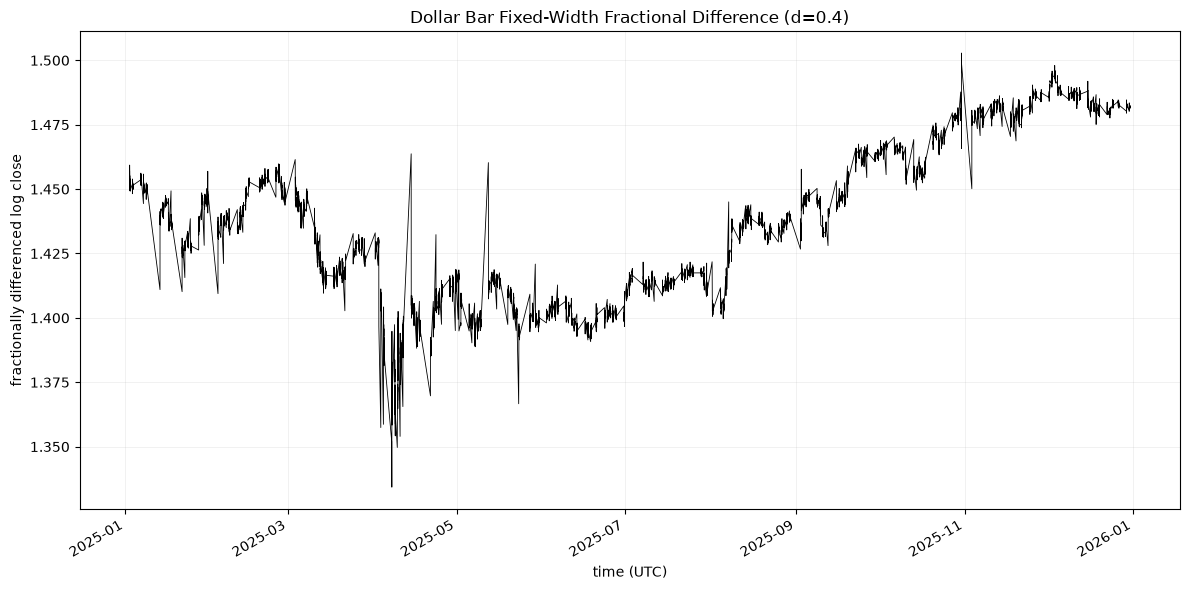

In [10]:
dollar_bar_fractionally_differenced_log_close = (
    fractional_difference_fixed_width(
        dollar_bar_log_close_frame,
        differencing_order=dollar_bar_selected_d,
        weight_cutoff=weight_cutoff,
    )
)
dollar_bar_fractional_bars = dollar_bars.loc[
    dollar_bar_fractionally_differenced_log_close.index,
    ["end"],
].copy()
dollar_bar_fractional_bars[
    "fractionally_differenced_log_close"
] = dollar_bar_fractionally_differenced_log_close["log_close"]

dollar_bar_fractional_output_path = feature_dir / (
    f"{symbol_slug}_dollar_bar_fractional_{period_slug}.parquet"
)
dollar_bar_fractional_bars.to_parquet(
    dollar_bar_fractional_output_path,
    index=False,
)

print(dollar_bar_fractional_output_path)
display(dollar_bar_fractional_bars.head())

dollar_bar_figure, dollar_bar_axis = plt.subplots(figsize=(12, 6))
dollar_bar_fractional_bars.set_index("end")[
    "fractionally_differenced_log_close"
].plot(ax=dollar_bar_axis, color="black", linewidth=0.6)
dollar_bar_axis.set_xlabel("time (UTC)")
dollar_bar_axis.set_ylabel("fractionally differenced log close")
dollar_bar_axis.set_title(
    "Dollar Bar Fixed-Width Fractional Difference "
    f"(d={dollar_bar_selected_d:.1f})"
)
dollar_bar_axis.grid(alpha=0.25)
dollar_bar_figure.tight_layout()
plt.show()